# look at a rolling T2m year and see what it looks like to maybe provide an argument why smoothing with Fourier is still better

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [15]:
input_year = 2023

# get this year and next year's daily mean t2m data
if input_year <= 1990:
    file_path = '../../../Data/ERA5-global/Baseline/' + str(input_year) + '/*.nc'
else:
    file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/*.nc'
ds = xr.open_mfdataset(file_path)

# load into memory to speed up the summer stats processing
ds.load()

# get summer stats for the year based on Fourier fits
file_path = '../../../Data/ERA5-global/Analysis/New-Fourier/' + str(input_year) + '_summer_stats.nc'
ds_summ = xr.open_dataset(file_path)
ds_summ.load()


#test for Vancouver
input_lat = 49.246
input_lon = -123.116
curr = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
curr_summ = ds_summ.sel(lat=input_lat, lon=input_lon, method="nearest")

In [16]:
curr, curr_summ

(<xarray.Dataset> Size: 6kB
 Dimensions:      (time: 365)
 Coordinates:
   * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
     realization  int64 8B 0
     lat          float64 8B 49.25
     lon          float64 8B -123.0
 Data variables:
     t2m          (time) float32 1kB 277.9 276.3 276.0 ... 283.0 283.1 279.9
     sst          (time) float32 1kB nan nan nan nan nan ... nan nan nan nan nan
 Attributes:
     Conventions:  CF-1.7
     institution:  European Centre for Medium-Range Weather Forecasts
     history:      2024-06-12T22:52 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
     source:       ECMWF,
 <xarray.Dataset> Size: 88B
 Dimensions:       ()
 Coordinates:
     lat           float64 8B 49.25
     lon           float64 8B -123.0
 Data variables:
     SummerStart   float64 8B 142.0
     SummerEnd     float64 8B 266.0
     SummerTmax    float64 8B 226.0
     SummerHeat    float64 8B 390.3
     SummerLength  float64 8B 125.0
     SummerRMSE    fl

In [5]:
# get baseline
file_path = '../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values


array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]], shape=(721, 1440))

In [6]:
# get threshold for this location
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
print(thresh)

<xarray.DataArray 't2m' ()> Size: 8B
array(286.88797)
Coordinates:
    lat       float64 8B 49.25
    lon       float64 8B -123.0
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K


In [12]:
%%time
# check computing the rolling avg for each grid cell

# min_periods = 2 to handle edges
ds_30dayroll2 = curr.t2m.rolling(time=30,center=True, min_periods=2).mean()
ds_30dayroll2


CPU times: user 14 ms, sys: 5.14 ms, total: 19.1 ms
Wall time: 16.2 ms


<xarray.DataArray 't2m' (time: 365)> Size: 1kB
array([279.3119 , 279.3032 , 279.28036, 279.25354, 279.08447, 278.95892,
       278.78238, 278.6446 , 278.5215 , 278.45648, 278.43866, 278.38998,
       278.36523, 278.34393, 278.16388, 277.9298 , 277.7458 , 277.6869 ,
       277.71075, 277.74152, 277.7309 , 277.68924, 277.6508 , 277.67313,
       277.59677, 277.5294 , 277.57712, 277.48224, 277.30652, 277.18695,
       277.05423, 276.89542, 276.7973 , 276.69708, 276.73642, 276.7657 ,
       276.8841 , 276.97238, 276.89703, 276.6652 , 276.36627, 276.158  ,
       276.02872, 275.8915 , 275.91858, 275.987  , 276.11893, 276.13297,
       276.1034 , 276.02634, 275.9181 , 275.84897, 275.7945 , 275.7381 ,
       275.79727, 275.7812 , 275.7202 , 275.75662, 275.74652, 275.73248,
       275.77783, 275.91733, 276.08664, 276.28897, 276.437  , 276.56317,
       276.60544, 276.6733 , 276.78647, 276.9917 , 277.2335 , 277.468  ,
       277.72375, 278.0316 , 278.24454, 278.43304, 278.47418, 278.51474,
       278.5383 , 278.56824, 278.61432, 278.6992 , 278.85275, 278.9417 ,
       279.02158, 279.10483, 279.1426 , 279.13275, 279.19675, 279.21603,
       279.32285, 279.3848 , 279.27887, 279.147  , 279.0429 , 278.93723,
       278.8835 , 278.89682, 279.06827, 279.2161 , 279.39072, 279.5122 ,
       279.5657 , 279.65366, 279.91226, 280.1708 , 280.40927, 280.72418,
       281.11505, 281.45526, 281.64856, 281.72266, 281.76755, 281.87454,
       281.98425, 282.14978, 282.39853, 282.7558 , 283.1806 , 283.699  ,
...
       288.73843, 288.57452, 288.2991 , 288.04205, 287.911  , 287.7416 ,
       287.57205, 287.36856, 287.12692, 286.91525, 286.81284, 286.79538,
       286.8234 , 286.83917, 286.877  , 286.8561 , 286.6714 , 286.48572,
       286.34766, 286.24472, 286.1859 , 286.08737, 285.97916, 285.8219 ,
       285.711  , 285.7492 , 285.76312, 285.68494, 285.61154, 285.44244,
       285.22623, 284.96844, 284.72424, 284.48654, 284.21475, 284.01547,
       283.83295, 283.63815, 283.47598, 283.432  , 283.3932 , 283.31662,
       283.18277, 282.98172, 282.76266, 282.47687, 282.30795, 282.1518 ,
       282.0761 , 281.91507, 281.69485, 281.3658 , 281.03058, 280.7908 ,
       280.53662, 280.27283, 280.0995 , 279.91455, 279.73782, 279.6632 ,
       279.62286, 279.53098, 279.447  , 279.38757, 279.39386, 279.3298 ,
       279.2332 , 279.13776, 279.02768, 278.8408 , 278.65848, 278.46143,
       278.3851 , 278.3109 , 278.16904, 278.03568, 277.89273, 277.79572,
       277.70566, 277.61935, 277.51566, 277.5878 , 277.69476, 277.76678,
       277.83508, 277.8861 , 277.89197, 277.9966 , 278.07523, 278.1093 ,
       278.0535 , 278.02646, 278.11652, 278.27548, 278.4267 , 278.65686,
       278.9117 , 279.16736, 279.29755, 279.37393, 279.42612, 279.44894,
       279.36755, 279.32224, 279.37704, 279.52393, 279.69962, 279.8085 ,
       279.86316, 279.99295, 280.16516, 280.222  , 280.24243],
      dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
    realization  int64 8B 0
    lat          float64 8B 49.25
    lon          float64 8B -123.0
Attributes:
    long_name:              2 metre temperature
    units:                  K
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real

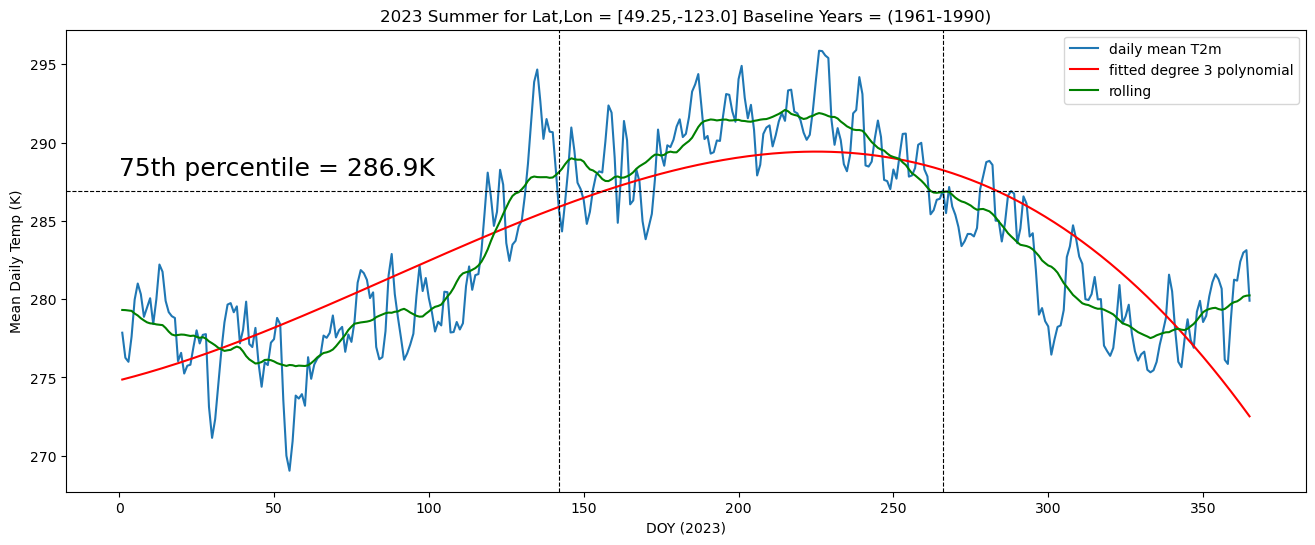

In [17]:




cell_lat = curr.lat.values
cell_lon = curr.lon.values
yr = curr.time.dt.year.values[0]
x1 = curr.time.dt.dayofyear.values
y1 = curr.t2m.values 

# polynomial fit, degree 3 as in Wang et al 2021
coefs = np.polyfit(x1, y1, 3)
poly = np.poly1d(coefs)

plt.figure(figsize=(16,6))
plt.plot(x1,y1, label='daily mean T2m')
plt.plot(x1, poly(x1), label='fitted degree 3 polynomial', color='red')
plt.plot(x1, ds_30dayroll2.values, color='green', label='rolling')
plt.axhline(thresh.values, color="black", linewidth=0.8, linestyle="dashed") 

plt.axvline(curr_summ.SummerStart, color="black", linewidth=0.8, linestyle="dashed")
plt.axvline(curr_summ.SummerEnd, color="black", linewidth=0.8, linestyle="dashed")

plt.xlabel('DOY (' + str(yr) + ')')
plt.ylabel('Mean Daily Temp (K)')
plt.annotate('75th percentile = '+str(np.round(thresh.values,1))+'K', xy=(0,thresh.values+1), fontsize=18)
plt.title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
plt.legend()
plt.show()